In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import rc
from fonts_config import set_computer_modern, truncate_colormap
set_computer_modern()
import matplotlib as mpl
mpl.rcParams['axes.unicode_minus'] = False
import glob
import os
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import colormaps as cmaps
import matplotlib.lines as mlines
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib import gridspec


In [2]:
#------------------------------------------------------
#  Paths
#------------------------------------------------------

best_sim_n=2572
leger=xr.open_dataset("../../FesmData/Leger2024_PaleoGris/output/paleogris_8km.nc")
best=xr.open_dataset(f"/p/projects/megarun/luciagu/data/tabone2024/ensemble_reduced/{best_sim_n}/yelmo2D_reduced.nc")
topo = xr.open_dataset("/p/projects/megarun/ice_data/Greenland/GRL-8KM/GRL-8KM_TOPO-M17.nc")
lgm=xr.open_dataset("/p/projects/megarun/luciagu/data/leger2024/lgm.nc")
lgm_leg = xr.where((lgm.mask==3)|(lgm.mask==2),1,0)

/tmp/ipykernel_224869/3470726509.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, lim)


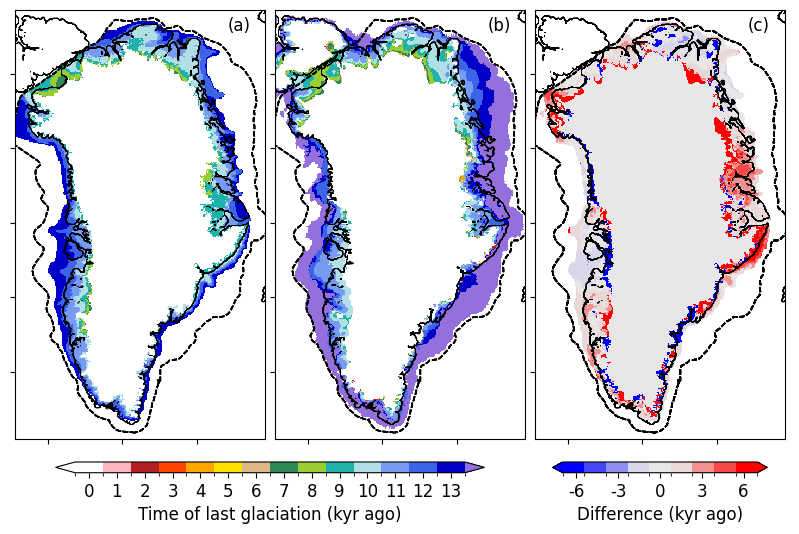

In [3]:
# ----------------------------------------------------------------------------
# Figure comparison best simulation vs Leger et al. (2024)
# ----------------------------------------------------------------------------
# f=15
fig = plt.figure(figsize=(7.8, 5.2))
gs = gridspec.GridSpec(2, 3,height_ratios=[3,0.5])
lim=14

cmap_name =	cmaps.amwg_r
cmap = cm.get_cmap(cmap_name, lim)
colors = cmap(np.arange(cmap.N))
colors[0] = [1, 1, 1, 1]
cmap = mcolors.ListedColormap(colors)

levels = np.linspace(-0.5, lim-0.5, lim+1)
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=cmap.N)

ax1=plt.subplot(gs[0,0])
im2 = ax1.pcolormesh(leger.xc,leger.yc,leger.age*1e-3, cmap=cmap, norm=norm, shading='auto')
ax1.text(0.85, 0.95,"(a)",  transform=ax1.transAxes)

ax2=plt.subplot(gs[0,1])
im2 = ax2.pcolormesh(best.xc,best.yc,best.isochrone, cmap=cmap, norm=norm, shading='auto')
ax2.text(0.85, 0.95,"(b)",  transform=ax2.transAxes)

ax3=plt.subplot(gs[0,2])
colors = ["blue", "#E8E6E6", "#E8E6E6", "red"]
nodes = [0.0, 0.4, 0.6, 1.0]
cmap_custom = mcolors.LinearSegmentedColormap.from_list("bwr_wide", list(zip(nodes, colors)))

diff = best.isochrone.values-leger.age.values*1e-3
# im_dif = ax3.contourf(best.xc,best.yc,diff,levels=np.linspace(-7,7,10), cmap=cmap_custom, extend="both")
norm=mcolors.BoundaryNorm(boundaries=np.linspace(-7,7,10), ncolors=cmap_custom.N)
im_dif = ax3.pcolormesh(best.xc,best.yc,diff, cmap=cmap_custom, norm=norm, shading='auto')

ax3.set_aspect(1)
ax3.tick_params(labelbottom=False, labelleft=False)
ax3.contour(topo.xc, topo.yc, topo.z_srf, levels=np.arange(0, 10, 1), colors='black', linewidths=0.5)
im_lgm=ax3.contour(lgm.xc, lgm.yc, lgm_leg, colors='black',  linestyles="dashed",linewidths=1)
ax3.text(0.85, 0.95,"(c)",  transform=ax3.transAxes)

for ax in [ax1, ax2, ax3]:
    ax.set_aspect(1)
    ax.tick_params(labelbottom=False, labelleft=False)
    ax.contour(topo.xc, topo.yc, topo.z_srf, levels=np.arange(0, 11, 1), colors='black', linewidths=0.5)
    im_lgm=ax.contour(lgm.xc, lgm.yc, lgm_leg, colors='black',  linestyles="dashed",linewidths=1)
    ax.set_xlim([topo.xc.min(), topo.xc.max()])
    ax.set_ylim([topo.yc.min(), topo.yc.max()])

# Legend
ax_cbar1 = plt.subplot(gs[1,0:2])
cbar = plt.colorbar(im2, ax=ax_cbar1,extend="both",orientation='horizontal',
                    ticks=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14],
                    aspect=40)
cbar.set_label("Time of last glaciation (kyr ago)")
cbar.ax.invert_yaxis()
ax_cbar2 = plt.subplot(gs[1,2])
cbar2 = plt.colorbar(im_dif, ax=ax_cbar2,extend="both",orientation='horizontal',
                    ticks=[-6,-3,0,3,6],)
cbar2.set_label("Difference (kyr ago)")

for ax in [ax_cbar1, ax_cbar2]:
    ax.axis('off')

plt.subplots_adjust(left=0,right=1,bottom=0.1,top=0.99,wspace=0,hspace=-0.15)

fig.savefig(f"../figs_final/fig6_{best_sim_n}_best_isochrones.pdf", dpi=300)
